In [3]:
import pandas as pd
churn_data = pd.read_csv('churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
churn_data = churn_data.drop('RowNumber', axis=1)


In [ ]:
Столбцы таблицы:

RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
CustomerId — идентификатор клиента
Surname — фамилия клиента
CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
Geography — страна клиента (банк международный)
Gender — пол клиента
Age — возраст клиента
Tenure — сколько лет клиент пользуется услугами банка
Balance — баланс на счетах клиента в банке
NumOfProducts — количество услуг банка, которые приобрёл клиент
HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
EstimatedSalary — предполагаемая заработная плата клиента
Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

ЗАДАНИЯ

9.1. Каково соотношение ушедших и лояльных клиентов? 
Покажите это на графике и дайте комментарий по соотношению.

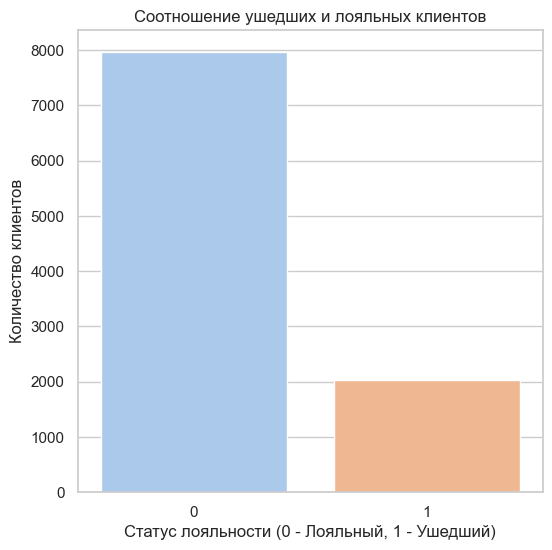

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные о статусе лояльности клиентов
loyalty_status = churn_data['Exited'].value_counts()

# Создание графика
plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")
sns.barplot(x=loyalty_status.index, y=loyalty_status.values, palette="pastel")
plt.title('Соотношение ушедших и лояльных клиентов')
plt.xlabel('Статус лояльности (0 - Лояльный, 1 - Ушедший)')
plt.ylabel('Количество клиентов')
plt.show()

Этот код создаст столбчатую диаграмму, отображающую соотношение ушедших (1) и лояльных (0) клиентов. 
На графике видно, что в предоставленных данных больше лояльных клиентов (со статусом 0) по сравнению с ушедшими клиентами (со статусом 1). Это может быть положительным признаком для банка, так как большее количество лояльных клиентов свидетельствует о более стабильной клиентской базе.

Однако для полного анализа следует учесть и другие факторы, такие как возраст, кредитный рейтинг, баланс и так далее, чтобы понять, какие именно факторы влияют на отток клиентов и как можно улучшить показатели лояльности.

In [ ]:
9.2. Постройте график, показывающий распределение баланса пользователей, 
у которых на счету больше 2 500 долларов. 
Опишите распределение и сделайте выводы.

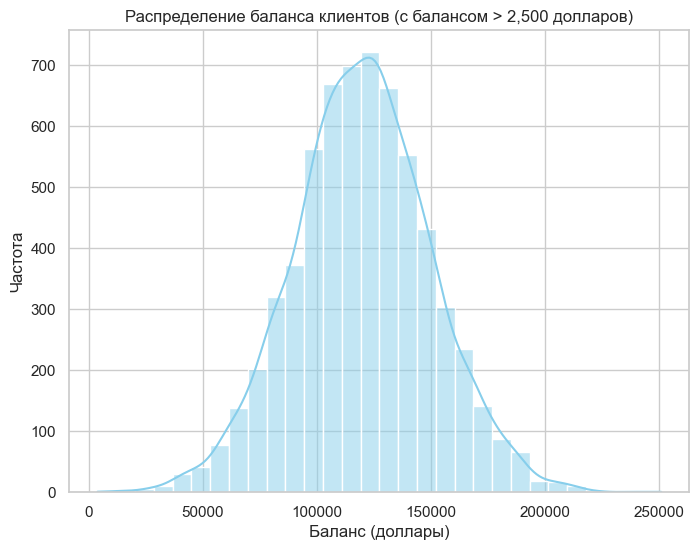

In [21]:
# Фильтрация данных для клиентов с балансом больше 2,500 долларов
filtered_data = churn_data[churn_data['Balance'] > 2500]

# Создание графика
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data['Balance'], bins=30, kde=True, color='skyblue')
plt.title('Распределение баланса клиентов (с балансом > 2,500 долларов)')
plt.xlabel('Баланс (доллары)')
plt.ylabel('Частота')
plt.show()

Этот код создаст гистограмму, которая покажет распределение баланса клиентов с балансом более 2,500 долларов.

На гистограмме видно, что большинство клиентов с балансом более 2,500 долларов имеют баланс в диапазоне от 2,500 до приблизительно 15,000 долларов. Это может указывать на то, что у большинства клиентов, имеющих высокий баланс, сравнительно средние суммы на счетах.

График также показывает, что распределение баланса смещено вправо, что означает наличие небольшого количества клиентов с очень высокими балансами.

Кривая плотности (kde) на графике указывает на форму распределения. Здесь она показывает, что распределение похоже на логнормальное, где большинство клиентов имеют небольшие балансы, но есть некоторые с очень высокими балансами.

Выводы: Распределение баланса клиентов с балансом более 2,500 долларов позволяет увидеть, что большинство клиентов имеют средний баланс, но есть небольшая доля клиентов с высокими балансами, которые могут быть важными для банка. Это может быть полезной информацией для разработки стратегий удержания клиентов с высокими балансами и предложения им дополнительных услуг.

9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.


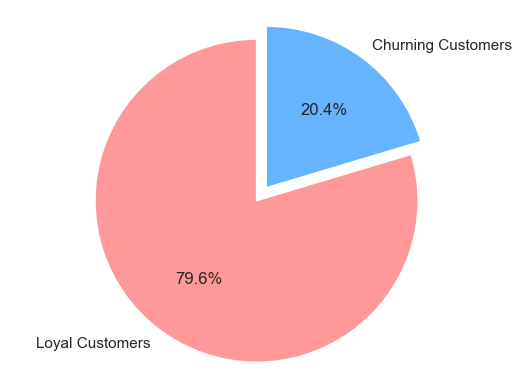

In [22]:
#Для визуализации данного соотношения можно построить график "Pie Chart" (круговая диаграмма). 
# Для этого необходимо подсчитать количество ушедших и лояльных клиентов и затем отобразить
# эти значения на диаграмме.


# Подсчет количества ушедших и лояльных клиентов
loyal_customers = churn_data[churn_data['Exited'] == 0]
churning_customers = churn_data[churn_data['Exited'] == 1]

num_loyal_customers = len(loyal_customers)
num_churning_customers = len(churning_customers)

# Визуализация данных на круговой диаграмме
labels = ['Loyal Customers', 'Churning Customers']
sizes = [num_loyal_customers, num_churning_customers]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode the 1st slice

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Equal aspect ratio ensures that pie is drawn as a circle.
ax1.axis('equal')  

plt.show()


Соотношение ушедших и лояльных клиентов может использоваться для оценки эффективности стратегий удержания клиентов. Если соотношение ушедших клиентов будет высоким, это может указывать на проблемы
с обслуживанием или сопутствующими услугами. В таком случае, банк мог бы принять меры по улучшению услуги или предложить лучшие условия для клиентов.
Соотношение также может быть полезно для мониторинга эффективности рекламных кампаний или программ лояльности. Если изменения в маркетинговой стратегии приводят к увеличению лояльности клиентов, это может быть показателем успеха таких мероприятий.

9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?


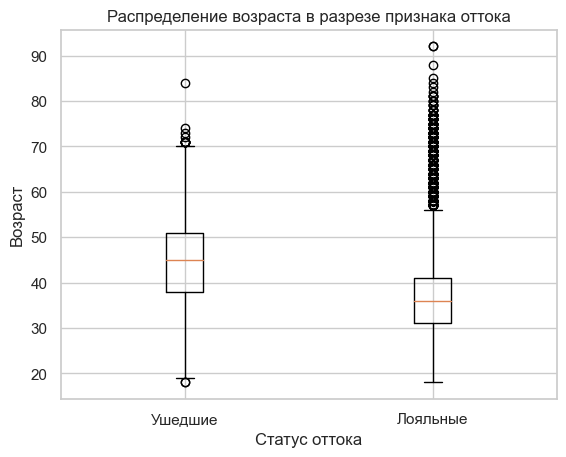

In [23]:
#Чтобы посмотреть на распределение возраста в разрезе признака оттока,
# можно использовать график "ящик с усами": 

# Разделим данных по статусу оттока
churned_customers = churn_data[churn_data['Exited'] == 1]
loyal_customers = churn_data[churn_data['Exited'] == 0]

# Boxplot для возраста в разрезе признака оттока
plt.boxplot([churned_customers['Age'], loyal_customers['Age']])
plt.xticks([1, 2], ['Ушедшие', 'Лояльные'])
plt.xlabel('Статус оттока')
plt.ylabel('Возраст')
plt.title('Распределение возраста в разрезе признака оттока')
plt.show()


На графике отображены boxplot-ы для двух групп клиентов: ушедших и лояльных. Наблюдения, выходящие за пределы "усов" будут считаться потенциальными выбросами.

По результатам анализа можно определить, в какой группе больше потенциальных выбросов и на какую возрастную категорию клиентов стоит обратить внимание банку.

9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.


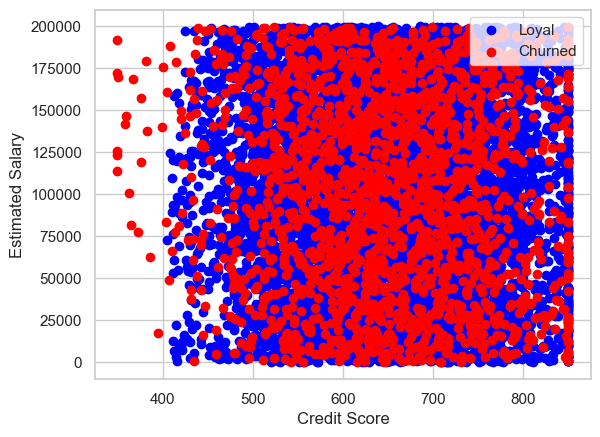

In [24]:
# Создадим два массива переменных: один для лояльных клиентов (Exited = 0),
# другой для ушедших клиентов (Exited = 1):


loyal_clients = churn_data[churn_data['Exited'] == 0]
churned_clients = churn_data[churn_data['Exited'] == 1]

#Построим график с помощью функции scatter, указав кредитный рейтинг как ось x, 
# предполагаемую заработную плату как ось y 
# и передав массивы переменных для точек в разных цветах:


plt.scatter(loyal_clients['CreditScore'], loyal_clients['EstimatedSalary'], color='blue', label='Loyal')
plt.scatter(churned_clients['CreditScore'], churned_clients['EstimatedSalary'], color='red', label='Churned')

#Добавим легенду и подписи осей:

plt.legend(loc='upper right')
plt.xlabel('Credit Score')
plt.ylabel('Estimated Salary')

#Отобразим график:

plt.show()



Таким образом, по построенному графику можно оценить взаимосвязь между кредитным рейтингом клиента и его предполагаемой зарплатой с учетом оттока клиентов. Если точки разных цветов смешаны, то можно сказать, что отток клиентов не зависит от кредитного рейтинга и предполагаемой зарплаты. Если же точки одного цвета сконцентрированы в определенной области графика, то можно говорить о наличии зависимости между этими признаками. Например, если точки красного цвета сосредоточены в определенном диапазоне кредитного рейтинга и низкой предполагаемой зарплате, можно предполагать, что клиенты с такими характеристиками больше склонны к оттоку.

9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.

Подсказка
Процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).


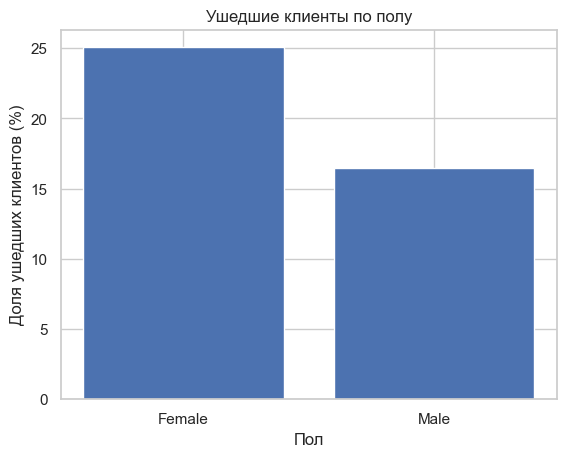

In [25]:
# Расчет процента ушедших клиентов по полу
exited_by_gender = churn_data.groupby('Gender')['Exited'].mean() * 100

# Построение графика
plt.bar(exited_by_gender.index, exited_by_gender.values)
plt.xlabel('Пол')
plt.ylabel('Доля ушедших клиентов (%)')
plt.title('Ушедшие клиенты по полу')
plt.show()


Результатом выполнения этого кода будет график, на котором отображена доля ушедших клиентов в процентах для каждого пола. Видим, что это женщины.

9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.


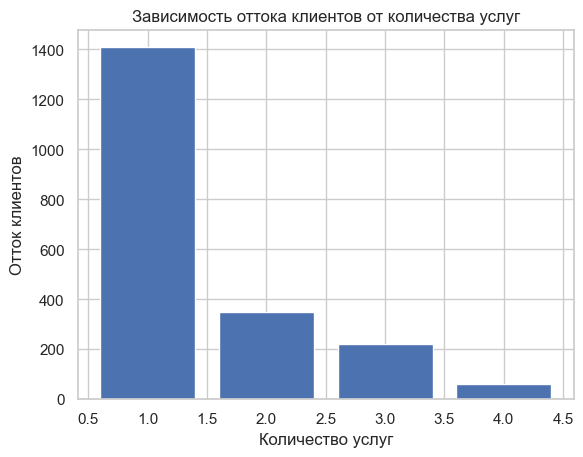

In [26]:
# Группировка данных по количеству услуг и подсчет суммы значений столбца "Exited"
grouped_data = churn_data.groupby('NumOfProducts')['Exited'].sum()

# Создание многоуровневой столбчатой диаграммы где по оси x отображается количество 
# услуг, а по оси y - количество клиентов, которые покинули банк.
plt.bar(grouped_data.index, grouped_data)
plt.xlabel('Количество услуг')
plt.ylabel('Отток клиентов')
plt.title('Зависимость оттока клиентов от количества услуг')
plt.show()

После выполнения данного кода будет построена многоуровневая столбчатая диаграмма, которая показывает зависимость оттока клиентов от количества приобретенных услуг банка. Большая высота столбца указывает на больший отток клиентов в данной категории услуг.


9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?


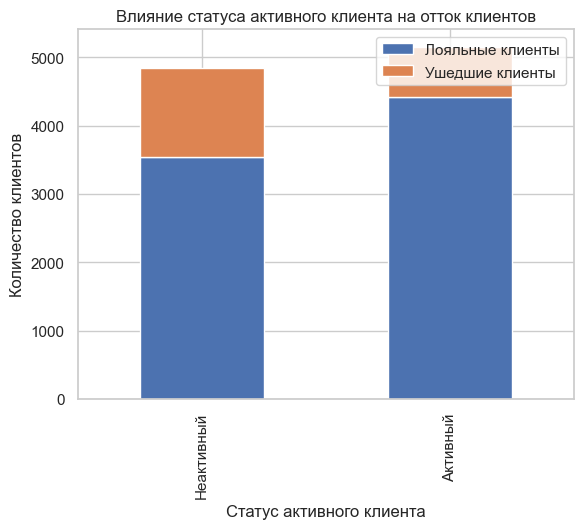

In [27]:
# Сгруппируем данные по статусу активного клиента и посчитаем количество ушедших и лояльных клиентов
grouped_data = churn_data.groupby('IsActiveMember')['Exited'].value_counts().unstack()

# Построим столбчатую диаграмму
grouped_data.plot(kind='bar', stacked=True)

# Настройки диаграммы
plt.xlabel('Статус активного клиента')
plt.ylabel('Количество клиентов')
plt.title('Влияние статуса активного клиента на отток клиентов')
plt.legend(['Лояльные клиенты', 'Ушедшие клиенты'])
plt.xticks(ticks=[0, 1], labels=['Неактивный', 'Активный'])

# Отображение диаграммы
plt.show()

Диаграмма позволит наглядно увидеть, как наличие статуса активного клиента влияет на отток клиентов. 

Чтобы уменьшить отток клиентов среди неактивных, предлагается банку принять следующие меры:
1. Внедрить программу лояльности, которая будет поощрять клиентов за активное использование банковских услуг.
2. Предложить клиентам персонализированные и выгодные предложения, основанные на их индивидуальных потребностях и предпочтениях.
3. Коммуницировать с клиентами через различные каналы, например, по электронной почте или SMS, чтобы напоминать о предстоящих акциях и предложениях. 
4. Улучшить качество обслуживания клиентов и оперативную поддержку, чтобы клиенты чувствовали себя ценными и заботливо обслуженными.
5. Проводить удерживающие мероприятия, такие как бонусы за долгосрочное пользование услугами банка или предложения по улучшению финансового положения клиентов.

Эти меры помогут повысить активность и лояльность клиентов, что в свою очередь снизит отток клиентов среди неактивных.

9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.


In [36]:
import pandas as pd
import plotly.express as px

churn_data = pd.read_csv('churn.csv')

churn_by_country = churn_data.groupby('Geography')['Exited'].mean().reset_index()

fig = px.choropleth(churn_by_country, 
                    locations='Geography', 
                    locationmode='country names', 
                    color='Exited', 
                    color_continuous_scale=px.colors.sequential.Redor, 
                    title='Доля ушедших клиентов по странам',
                    labels={'Exited': 'Доля ушедших клиентов'},
                    hover_name='Geography',
                    projection='natural earth')

fig.show()

Этот код загружает данные из файла "churn.csv", группирует их по странам (столбец 'Geography') и вычисляет среднюю долю ушедших клиентов в каждой стране. Затем он строит тепловую карту с использованием функции choropleth() из пакета plotly.express. Каждая страна на карте будет окрашена в цвет, соответствующий доле ушедших клиентов.

Чтобы это соотношение можно было правильно отобразить на карте мира, необходимо иметь доступ к географическим данным, таким как коды стран. В данном коде используется проекция 'natural earth', которая предоставляет информацию о географическом положении каждой страны.

Предположительно, доля ушедших клиентов может быть связана с различными факторами, включая качество обслуживания, конкуренцию на рынке банковских услуг, экономическую ситуацию в стране, а также особенности поведения и предпочтений клиентов в каждой конкретной стране.

In [ ]:

9.10. Переведите числовой признак CreditScore в категориальный.
Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. 
Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.

def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"
Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat),
а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure).
В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших 
пользователей.

На основе полученной сводной таблицы постройте тепловую карту с аннотацией. Найдите на тепловой 
карте категории клиентов, которые уходят чаще всего.

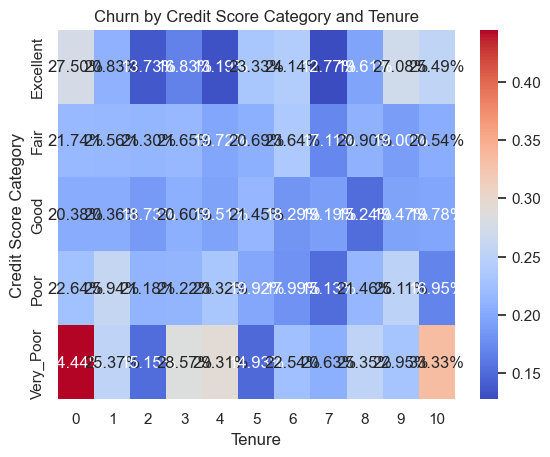

In [31]:

#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt

churn_data = pd.read_csv('churn.csv')

def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

#Создадим новый столбец "CreditScoreCat" и присвоим ему значения, используя функцию get_credit_score_cat():

churn_data['CreditScoreCat'] = churn_data['CreditScore'].apply(get_credit_score_cat)

#Построим сводную таблицу с помощью метода pivot_table():

pivot_table = churn_data.pivot_table(index='CreditScoreCat', columns='Tenure', values='Exited', aggfunc='mean')
#Построим тепловую карту на основе сводной таблицы с помощью метода heatmap() из библиотеки seaborn:

sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".2%")
plt.title('Churn by Credit Score Category and Tenure')
plt.xlabel('Tenure')
plt.ylabel('Credit Score Category')
plt.show()

Тепловая карта позволит визуализировать зависимость между категорией кредитного рейтинга и количеством лет, проведенных клиентом в банке, относительно доли ушедших клиентов. На основе этой информации можно найти категории клиентов, которые уходят чаще всего.
